In [5]:
#Setting up data generation and ML training for fitting fNi from light curves. Through research, I learned that in order for the full SN LC to be sent into the MLP, I need to store the data as seen as the end of this block.

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from scipy.integrate import odeint

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_SNE = 600
N_TIME = 1000
T_MAX_DAYS = 200.0

t_days = np.linspace(0.0, T_MAX_DAYS, N_TIME, dtype=np.float32)

# Fixed physical-ish params for now (only fNi varies)
M = 1.3 * 1.989e33   # g
kappa = 0.33
v = 1.0e9  
DAY_TO_SEC = 86400.0
C = 3.0e10
B = 13.8
R0 = 1.0e15
L0_DEFAULT = 1.0e42

def qdot_per_g(t_day: float) -> float:
    return (
        3.9e10 * np.exp(-t_day / 8.8)
        + 6.78e9 * (np.exp(-t_day / 111.3) - np.exp(-t_day / 8.8))
    )

def simulate_single_curve(
    t_days: np.ndarray,
    *,
    fNi: float,
    M: float,
    kappa: float,
    v: float,
    L0: float = L0_DEFAULT,
    add_noise: bool = False,
    noise_frac: float = 0.03,
) -> np.ndarray:

    # ensure times are float64 for scipy.odeint
    t_days = np.asarray(t_days, dtype=np.float64)

    # diffusion-ish timescales (days)
    t0 = (kappa * M) / (B * C * R0) / DAY_TO_SEC
    th = (R0 / v) / DAY_TO_SEC
    t_lc = np.sqrt(2.0 * t0 * th)

    # odeint expects func(y, t)
    def dLdt(L, t_day):
        Qdot_total = fNi * M * qdot_per_g(t_day)  # erg/s
        return ((t_day + t0) / (t_lc ** 2)) * (Qdot_total - L)

    y0 = float(L0)
    # integrate in float64 to avoid overflow/precision issues
    L = odeint(dLdt, y0, t_days).flatten().astype(np.float64)

    # optional relative Gaussian noise (robust casting and clipping)
   
    return L
    

def simulate_dataset(
    *,
    n_sne: int,
    t_days: np.ndarray,
    fNi_min: float = 0.2,
    fNi_max: float = 0.6,
    M: float = 1.3 * 1.989e33,
    kappa: float = 0.33,
    v: float = 1.0e9,
    add_noise: bool = True,
    noise_frac: float = 0.03,
):
    fNi_values = np.random.uniform(fNi_min, fNi_max, size=n_sne).astype(np.float32)
    curves = []
    for f in fNi_values:
        curves.append(
            simulate_single_curve(
                t_days,
                fNi=float(f),
                M=M,
                kappa=kappa,
                v=v,
                L0=L0_DEFAULT,
                add_noise=add_noise,
                noise_frac=noise_frac,
            )
        )
    L_curves = np.stack(curves).astype(np.float64)
    return L_curves, fNi_values

L_curves, fNi_values = simulate_dataset(
    n_sne=N_SNE,
    t_days=t_days,
    fNi_min=0.2,
    fNi_max=0.6,
    M=M,
    kappa=kappa,
    v=v,
    
)

print("L_curves shape:", L_curves.shape)  # (N_SNE, N_TIME)
print("fNi_values shape:", fNi_values.shape)  # (N_SNE,)

assert L_curves.shape == (N_SNE, N_TIME)
assert fNi_values.shape == (N_SNE,)

# Save the dataset (INCLUDING the fNi values used)
out_path = "sn_lightcurves_varying_fNi.npz"
np.savez_compressed(
    out_path,
    t_days=t_days,
    L_curves=L_curves,
    fNi=fNi_values,
    M=M,
    kappa=kappa,
    v=v,
    seed=SEED,
)
print("Saved dataset to:", out_path)


L_curves shape: (600, 1000)
fNi_values shape: (600,)
Saved dataset to: sn_lightcurves_varying_fNi.npz


In [6]:

# 2)Allign data types  and sizes to make sure it can be processed through Neural Network

eps = 1e-6

logL = np.log10(L_curves + eps).astype(np.float64)  # (N_SNE, N_TIME)
t_norm = (t_days - t_days.min()) / (t_days.max() - t_days.min())  # (N_TIME,)
t_tile = np.tile(t_norm[None, :], (N_SNE, 1)).astype(np.float32)
mu = logL.mean(axis=0, keepdims=True)
sigma = logL.std(axis=0, keepdims=True) + 1e-6
logL_std = (logL - mu) / sigma
X_np = np.concatenate([t_tile.astype(np.float64), logL_std], axis=1).astype(np.float32)   # (N_SNE, 2*N_TIME)
y_np = fNi_values.reshape(-1, 1).astype(np.float32)  # (N_SNE, 1)



# Torch tensors (FULL dataset)
X_all_t = torch.from_numpy(X_np)
y_all_t = torch.from_numpy(y_np)

print("All data:", X_all_t.shape, y_all_t.shape)
print("X_np:", X_np.shape, " y_np:", y_np.shape)


All data: torch.Size([600, 2000]) torch.Size([600, 1])
X_np: (600, 2000)  y_np: (600, 1)


In [7]:
# -----------------------
# 3) Standard MLP model we have been using
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_size = X_all_t.shape[1]  # = 2*N_TIME

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        super(MLP, self).__init__()
        torch.manual_seed(seed)
        
        # Layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 =nn.Linear(hidden_size, output_size)

    

    def forward(self, x):
        
        x = torch.nn.functional.leaky_relu(self.fc1(x))
        # No Softmax here! We want a continuous number for regression.
        x = torch.nn.functional.leaky_relu(self.fc2(x))
        x = torch.nn.functional.leaky_relu(self.fc3(x))
        x = self.fc4(x)
        return x

model = MLP(input_size=input_size, hidden_size=256, output_size=1).to(device)
print(model)
print("Input size:", input_size)


Using device: cpu
MLP(
  (fc1): Linear(in_features=2000, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=1, bias=True)
)
Input size: 2000


Epoch 001 | train MSE 1.857043e-02
Epoch 020 | train MSE 1.363344e-06
Epoch 040 | train MSE 2.041955e-06
Epoch 060 | train MSE 1.257067e-05
Epoch 080 | train MSE 7.771328e-07
Epoch 100 | train MSE 1.025282e-03
Epoch 120 | train MSE 9.506574e-08
Epoch 140 | train MSE 2.205320e-05
Epoch 160 | train MSE 4.087107e-06
Epoch 180 | train MSE 5.849456e-08
Epoch 200 | train MSE 5.684016e-04
Epoch 220 | train MSE 1.092727e-07
Epoch 240 | train MSE 4.362964e-05
Epoch 260 | train MSE 6.927307e-07
Epoch 280 | train MSE 2.587233e-07
Epoch 300 | train MSE 7.537720e-07
Epoch 320 | train MSE 6.339737e-06
Epoch 340 | train MSE 5.716645e-07
Epoch 360 | train MSE 4.028829e-07
Epoch 380 | train MSE 6.387888e-06
Epoch 400 | train MSE 1.976038e-07
Epoch 420 | train MSE 2.905186e-06
Epoch 440 | train MSE 4.256873e-06
Epoch 460 | train MSE 1.115258e-06
Epoch 480 | train MSE 8.588492e-06
Epoch 500 | train MSE 6.974452e-06
Restored best model with train MSE: 2.6028346719423706e-08


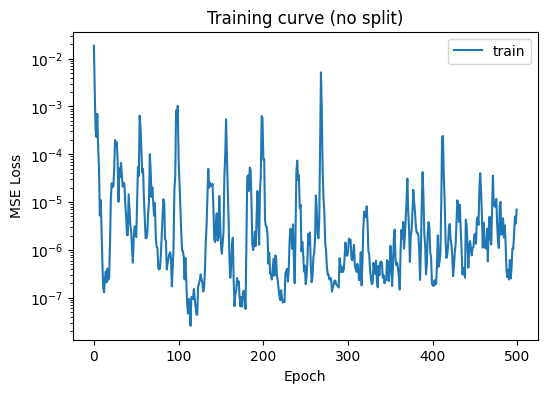

In [ ]:

# 4) TRAINING LOOP (iterates over SUPER-NOVAE)
batch_size = 32
train_loader = DataLoader(TensorDataset(X_all_t, y_all_t), batch_size=batch_size, shuffle=True)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

def evaluate_on_all():
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total += loss.item() * xb.size(0)
            n += xb.size(0)
    return total / max(n, 1)

train_losses = []

EPOCHS = 500
best_train = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    n = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)
        n += xb.size(0)

    train_loss = running / max(n, 1)
    train_losses.append(train_loss)

    # keep best in-sample model (useful if loss jitters)
    if train_loss < best_train:
        best_train = train_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train MSE {train_loss:.6e}")

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best model with train MSE:", best_train)

# Loss curve
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training curve (no split)")
plt.legend()
plt.show()


All-data MAE:  0.00014
All-data RMSE: 0.00017
All-data R^2:  1.00000


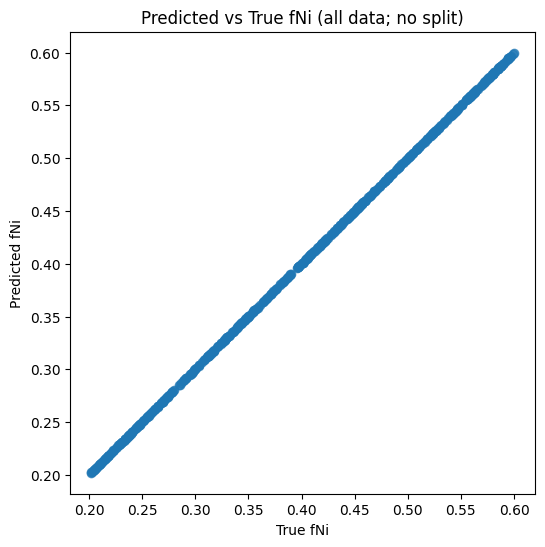

In [ ]:
# -----------------------
# 5) EVALUATION (in-sample, since no split)
# -----------------------
full_loader = DataLoader(TensorDataset(X_all_t, y_all_t), batch_size=64, shuffle=False)

model.eval()
preds = []
trues = []
with torch.no_grad():
    for xb, yb in full_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy().reshape(-1)
        preds.append(pred)
        trues.append(yb.numpy().reshape(-1))

preds = np.concatenate(preds)
trues = np.concatenate(trues)

mae = np.mean(np.abs(preds - trues))
rmse = np.sqrt(np.mean((preds - trues) ** 2))
# simple R^2
ss_res = np.sum((preds - trues) ** 2)
ss_tot = np.sum((trues - trues.mean()) ** 2) + 1e-12
r2 = 1.0 - ss_res / ss_tot

print(f"All-data MAE:  {mae:.5f}")
print(f"All-data RMSE: {rmse:.5f}")
print(f"All-data R^2:  {r2:.5f}")

plt.figure(figsize=(6, 6))
plt.scatter(trues, preds, alpha=0.7)
lo = float(min(trues.min(), preds.min()))
hi = float(max(trues.max(), preds.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("True fNi")
plt.ylabel("Predicted fNi")
plt.title("Predicted vs True fNi ")
plt.show()
